In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [2]:
import matplotlib.pyplot as plt

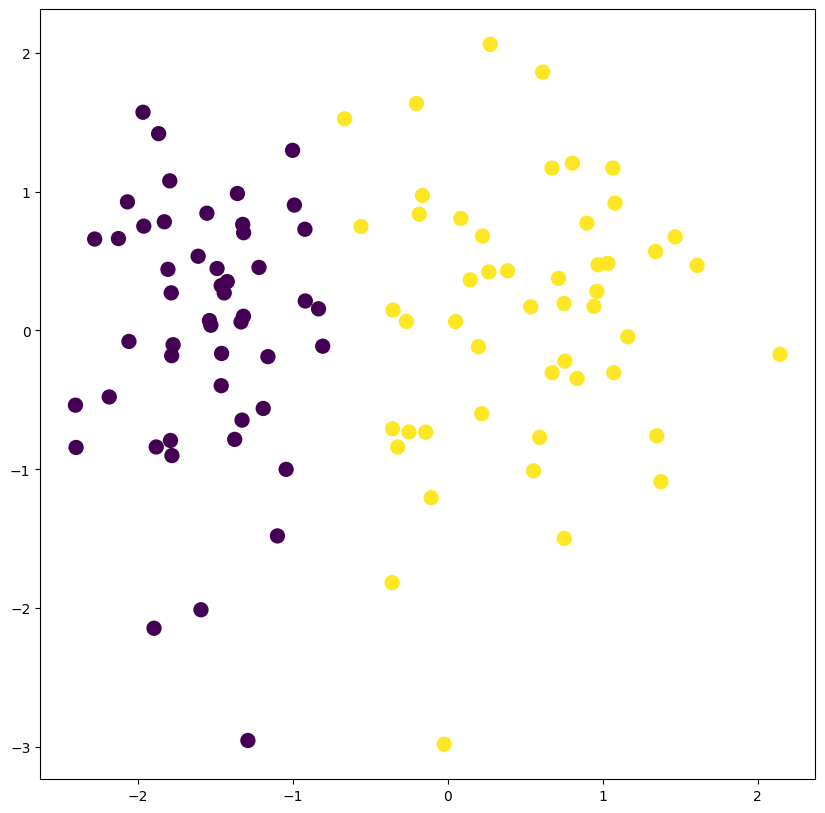

In [4]:
plt.figure(figsize=(10,10))
plt.scatter(X[:,0],X[:,1],c=y,s=100)
plt.show()

In [6]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [7]:
def step(z):
  return 1 if z>0 else 0

In [8]:
intercept_,coef_ = perceptron(X,y)

In [9]:
print(coef_)
print(intercept_)

[1.33965617 0.18627077]
0.9


In [11]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

Let's say we have the following coefficients:

coef_ = [2, 3] (where coef_[0] = 2 and coef_[1] = 3)
intercept_ = 1
Now, we can calculate:

Slope:
m=−
3
2
​
 ≈−0.67
Intercept:
c=−
3
1
​
 ≈−0.33

In [12]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

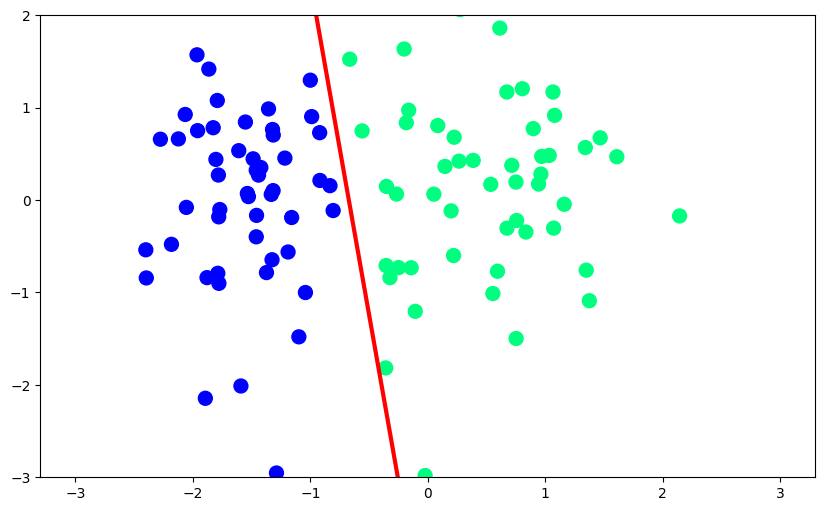

In [14]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()


In [15]:
def perceptron(X,y):

    m = []
    b = []

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))

    return m,b

In [16]:
m,b = perceptron(X,y)


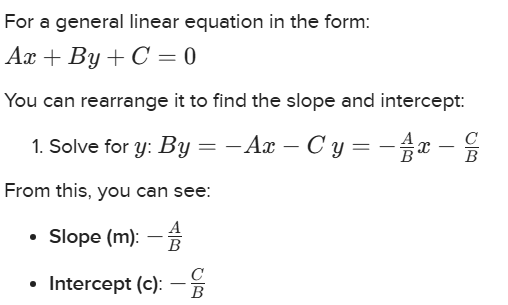

In [17]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [20]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
plt.show()
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
anim

<IPython.core.display.Javascript object>

In [21]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [22]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [23]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

In [24]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

<IPython.core.display.Javascript object>

(-3.0, 2.0)

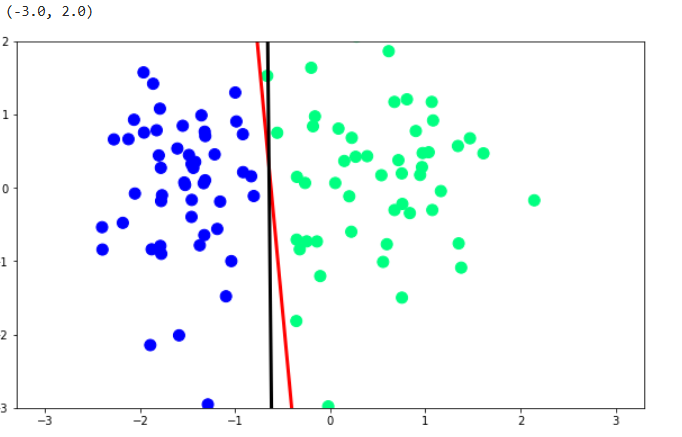

In [25]:
import numpy as np

def perceptron(X, y, lr=0.1, epochs=1000):
    # Initialize weights and bias
    weights = np.zeros(X.shape[1])
    bias = 0

    for epoch in range(epochs):
        for i in range(len(X)):
            # Calculate the linear output
            linear_output = np.dot(X[i], weights) + bias
            # Apply the step function to get the predicted label
            y_hat = 1 if linear_output >= 0 else 0

            # Update weights and bias if there is a misclassification
            if y[i] != y_hat:
                weights += lr * (y[i] - y_hat) * X[i]
                bias += lr * (y[i] - y_hat)

    return weights, bias

# Example usage
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # Input features (AND gate)
y = np.array([0, 0, 0, 1])  # Target labels
weights, bias = perceptron(X, y)
print("Weights:", weights)
print("Bias:", bias)


Weights: [0.2 0.1]
Bias: -0.20000000000000004
